In [80]:
# Config
from pathlib import Path
import os

# Simply set the CSV path here (no searching)
CSV_PATH = '../training_gradient_evaluator_single_loss/outputs_archive/outputs/efficientvit_b2.r224_in1k/single_example_results.csv'

SEED = 1337
TEST_SIZE = 0.10
VAL_SIZE = 0.05  # of the total dataset (will be normalized after test split)
TARGET_COLUMN = 'universal_difficulty_rank'
FEATURE_COLUMNS = [
    'total_steps_to_epsilon',
    'total_loss_sum',
    'final_loss',
    'weight_distance',
    'softmax_wasserstein',
    'grad_mass_wasserstein',
]
SAVE_MODELS = True
ARTIFACTS_DIRNAME = 'rank_predictor_artifacts'

In [81]:
# Imports
import json
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import RegressorChain
from sklearn.base import BaseEstimator, RegressorMixin

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib
import matplotlib.pyplot as plt

random.seed(SEED)
np.random.seed(SEED)


In [82]:
# Stronger models: ElasticNet and CatBoost
from sklearn.linear_model import ElasticNet


def build_stronger_regressors(seed: int):
	models = {
		"elasticnet": ElasticNet(alpha=0.001, l1_ratio=0.3, random_state=seed, max_iter=20000),
		"catboost": CatBoostRegressor(
			depth=8,
			learning_rate=0.03,
			n_estimators=1500,
			subsample=0.8,
			loss_function='RMSE',
			random_state=seed,
			verbose=False,
		),
	}
	return models


def fit_stronger(train_df: pd.DataFrame, val_df: pd.DataFrame, feature_cols: list[str], target_col: str, seed: int):
	models = build_stronger_regressors(seed)
	metrics = {}
	best_name = None
	best_score = float('inf')
	best_model = None
	for name, est in models.items():
		pipe = build_pipeline(est, feature_cols)
		pipe.fit(train_df[feature_cols], train_df[target_col].values)
		m = evaluate_model(pipe, val_df[feature_cols], val_df[target_col].values)
		metrics[name] = m
		if m["mae"] < best_score:
			best_score = m["mae"]
			best_name = name
			best_model = pipe
	return best_name, best_model, metrics



In [83]:
# Baseline single-feature models and correlations
from scipy.stats import pearsonr

def baseline_single_feature_scores(df, feature_cols, target_col):
	results = {}
	for col in feature_cols:
		x = df[[col]].values.reshape(-1, 1)
		y = df[target_col].values
		# Simple linear regression baseline (Ridge with alpha=0)
		from sklearn.linear_model import LinearRegression
		lr = LinearRegression()
		mask = ~pd.isna(df[col])
		if mask.sum() < 10:
			continue
		lr.fit(x[mask], y[mask])
		pred = lr.predict(x[mask])
		mae = float(mean_absolute_error(y[mask], pred))
		r2 = float(r2_score(y[mask], pred))
		try:
			corr, _ = pearsonr(y[mask], pred)
		except Exception:
			corr = float('nan')
		results[col] = {"mae": mae, "r2": r2, "pearson_r": float(corr)}
	return results



### Metric and model key descriptions
- rf: Random Forest regressor (bagged decision trees)
- hgb: Histogram Gradient Boosting regressor (tree boosting with histograms)
- xgb: XGBoost regressor (optimized gradient boosting decision trees)
- mae: Mean Absolute Error (average absolute difference between predictions and true ranks)
- r2: Coefficient of Determination (1 is perfect fit; 0 means no better than mean; negative is worse)



In [84]:
# Utilities

def find_model_result_csvs(root: Path, csv_name: str) -> dict:
	"""Return mapping: model_dir_path -> csv_path."""
	root = Path(root)
	mapping = os.path.join(root, csv_name)
	return mapping


def load_dataset(csv_path: str, feature_cols: list[str], target_col: str) -> pd.DataFrame:
	df = pd.read_csv(csv_path)
	# Ensure required columns exist; missing feature columns will be added as NaN
	for c in feature_cols + [target_col, 'path', 'example_index']:
		if c not in df.columns:
			df[c] = np.nan
	return df


def split_train_val_test(df: pd.DataFrame, test_size: float, val_size: float, seed: int):
	# First split off test
	train_val, test = train_test_split(df, test_size=test_size, random_state=seed, shuffle=True)
	# Val proportion relative to remaining
	val_rel = val_size / max(1e-9, (1.0 - test_size))
	train, val = train_test_split(train_val, test_size=val_rel, random_state=seed, shuffle=True)
	return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)


def build_regressors(seed: int):
	models = {
		"hgb": HistGradientBoostingRegressor(random_state=seed, max_depth=None, learning_rate=0.05, max_iter=500),
		"rf": RandomForestRegressor(random_state=seed, n_estimators=600, max_depth=None, n_jobs=-1, oob_score=False),
		"xgb": XGBRegressor(
			random_state=seed,
			n_estimators=800,
			max_depth=8,
			learning_rate=0.05,
			subsample=0.8,
			colsample_bytree=0.8,
			tree_method='hist',
			reg_lambda=1.0,
		),
		"ridge": Ridge(random_state=seed),
	}
	return models


def build_pipeline(estimator, numeric_features: list[str]) -> Pipeline:
	preprocess = ColumnTransformer(
		transformers=[
			("num", Pipeline(steps=[
				("imputer", SimpleImputer(strategy="median")),
				("scaler", StandardScaler()),
			]), numeric_features),
		], remainder='drop'
	)
	pipe = Pipeline(steps=[
		("preprocess", preprocess),
		("regressor", estimator),
	])
	return pipe


def evaluate_model(model: Pipeline, X: pd.DataFrame, y: np.ndarray) -> dict:
	pred = model.predict(X)
	mae = float(mean_absolute_error(y, pred))
	r2 = float(r2_score(y, pred))
	return {"mae": mae, "r2": r2}


def fit_ensemble(train_df: pd.DataFrame, val_df: pd.DataFrame, feature_cols: list[str], target_col: str, seed: int):
	models = build_regressors(seed)
	metrics = {}
	best_name = None
	best_score = float('inf')
	best_model = None
	for name, est in models.items():
		pipe = build_pipeline(est, feature_cols)
		pipe.fit(train_df[feature_cols], train_df[target_col].values)
		m = evaluate_model(pipe, val_df[feature_cols], val_df[target_col].values)
		metrics[name] = m
		if m["mae"] < best_score:
			best_score = m["mae"]
			best_name = name
			best_model = pipe
	return best_name, best_model, metrics


def save_artifacts(model_dir: Path, model_name: str, best_name: str, model: Pipeline, metrics: dict, feature_cols: list[str]) -> None:
	art_dir = Path(model_dir) / ARTIFACTS_DIRNAME
	art_dir.mkdir(parents=True, exist_ok=True)
	joblib.dump(model, art_dir / f"best_model_{best_name}.joblib")
	with open(art_dir / "metrics.json", 'w', encoding='utf-8') as f:
		json.dump(metrics, f, indent=2)
	with open(art_dir / "features.json", 'w', encoding='utf-8') as f:
		json.dump({"feature_columns": feature_cols, "target": TARGET_COLUMN}, f, indent=2)



In [85]:
# Direct CSV path usage
CSV_PATH


'../training_gradient_evaluator_single_loss/outputs_archive/outputs/efficientvit_b2.r224_in1k/single_example_results.csv'

CSV: ../training_gradient_evaluator_single_loss/outputs_archive/outputs/efficientvit_b2.r224_in1k/single_example_results.csv
Total rows loaded: 2842
Using features: ['total_steps_to_epsilon', 'total_loss_sum', 'final_loss', 'weight_distance', 'softmax_wasserstein', 'grad_mass_wasserstein']
Rows with target present: 2842
Split sizes -> train: 2414, val: 143, test: 285
Single-feature baselines (train): top by R2:
  softmax_wasserstein: MAE=2310.95, R2=0.2133, r=0.4618
  total_loss_sum: MAE=2576.83, R2=0.0404, r=0.2010
  final_loss: MAE=2636.65, R2=0.0015, r=0.0391
  total_steps_to_epsilon: MAE=2645.41, R2=0.0002, r=0.0137
  grad_mass_wasserstein: MAE=2639.33, R2=0.0001, r=0.0102
All validation metrics by model:
  hgb: MAE=2147.1829, R2=0.2322
  rf: MAE=1963.3643, R2=0.3435
  xgb: MAE=2037.6661, R2=0.2826
  ridge: MAE=2283.1071, R2=0.2370
Best model on val: rf
Test metrics: MAE=1977.4990, R2=0.3669
Correlation (train): r=0.9668
Correlation (test):  r=0.6076


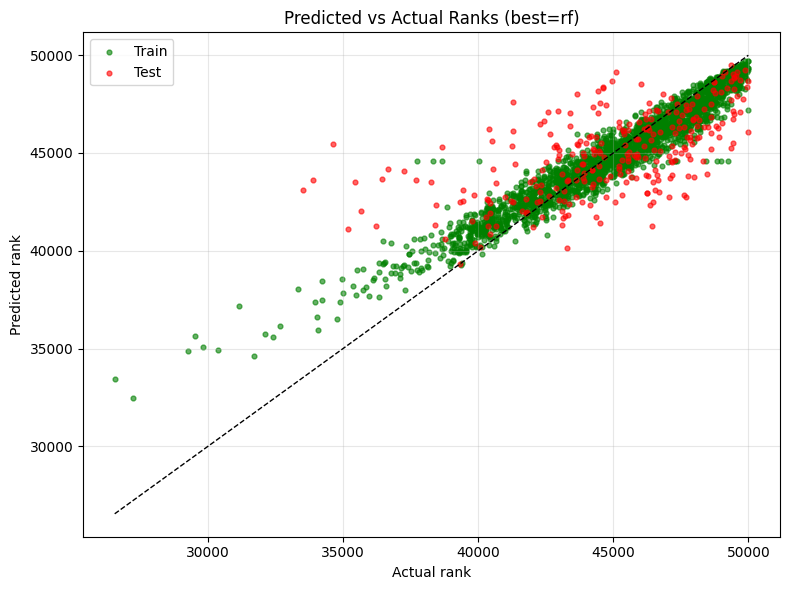

{'csv': '../training_gradient_evaluator_single_loss/outputs_archive/outputs/efficientvit_b2.r224_in1k/single_example_results.csv',
 'best_model': 'rf',
 'metrics': {'hgb': {'mae': 2147.18292006806, 'r2': 0.23221094453530433},
  'rf': {'mae': 1963.364329078188, 'r2': 0.3435254425847195},
  'xgb': {'mae': 2037.6661376953125, 'r2': 0.2825855612754822},
  'ridge': {'mae': 2283.1071000903794, 'r2': 0.23696204380273989},
  'test': {'mae': 1977.4989851014914, 'r2': 0.3669025709082725}}}

In [86]:
# Fit on a single CSV

def train_and_evaluate_single(csv_path: str,
                             feature_cols=FEATURE_COLUMNS,
                             target_col=TARGET_COLUMN,
                             seed=SEED,
                             test_size=TEST_SIZE,
                             val_size=VAL_SIZE,
                             save_models=SAVE_MODELS):
	print(f"CSV: {csv_path}")
	df = load_dataset(csv_path, feature_cols, target_col)
	print(f"Total rows loaded: {len(df)}")
	print(f"Using features: {feature_cols}")
	df = df.dropna(subset=[target_col])
	print(f"Rows with target present: {len(df)}")
	if df.empty:
		print("No data.")
		return None
	train_df, val_df, test_df = split_train_val_test(df, test_size, val_size, seed)
	print(f"Split sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
	# Baseline single-feature correlations (train)
	baseline = baseline_single_feature_scores(train_df, feature_cols, target_col)
	if baseline:
		print("Single-feature baselines (train): top by R2:")
		for k, v in sorted(baseline.items(), key=lambda kv: kv[1]['r2'], reverse=True)[:5]:
			print(f"  {k}: MAE={v['mae']:.2f}, R2={v['r2']:.4f}, r={v['pearson_r']:.4f}")
	# Fit classic ensemble and stronger models
	best_name, best_model, metrics = fit_ensemble(train_df, val_df, feature_cols, target_col, seed)
	best_name2, best_model2, metrics2 = fit_stronger(train_df, val_df, feature_cols, target_col, seed)
	# Choose overall best by val MAE
	cand = [(best_name, best_model, metrics), (best_name2, best_model2, metrics2)]
	chosen = min(cand, key=lambda x: x[2][x[0]]["mae"]) if all(c[0] is not None for c in cand) else cand[0]
	best_name, best_model, metrics = chosen
	print("All validation metrics by model:")
	allm = {**metrics}
	for name, m in allm.items():
		if name == 'test':
			continue
		print(f"  {name}: MAE={m['mae']:.4f}, R2={m['r2']:.4f}")
	# Evaluate on test and correlations
	test_metrics = evaluate_model(best_model, test_df[feature_cols], test_df[target_col].values)
	metrics['test'] = test_metrics
	print(f"Best model on val: {best_name}")
	print(f"Test metrics: MAE={test_metrics['mae']:.4f}, R2={test_metrics['r2']:.4f}")
	from scipy.stats import pearsonr
	train_pred = best_model.predict(train_df[feature_cols])
	test_pred = best_model.predict(test_df[feature_cols])
	train_r, _ = pearsonr(train_df[target_col].values, train_pred)
	test_r, _ = pearsonr(test_df[target_col].values, test_pred)
	print(f"Correlation (train): r={float(train_r):.4f}")
	print(f"Correlation (test):  r={float(test_r):.4f}")
	# Plot predicted vs actual for train and test
	# Plot predicted vs actual for train and test
	plt.figure(figsize=(8, 6))
	plt.scatter(train_df[target_col].values, train_pred, s=12, alpha=0.6, c='green', label='Train')
	plt.scatter(test_df[target_col].values, test_pred, s=12, alpha=0.6, c='red', label='Test')
	min_r = float(min(train_df[target_col].min(), test_df[target_col].min()))
	max_r = float(max(train_df[target_col].max(), test_df[target_col].max()))
	plt.plot([min_r, max_r], [min_r, max_r], 'k--', linewidth=1)
	plt.xlabel('Actual rank')
	plt.ylabel('Predicted rank')
	plt.title(f'Predicted vs Actual Ranks (best={best_name})')
	plt.legend()
	plt.grid(True, alpha=0.3)
	plt.tight_layout()
	if save_models:
		plot_path = Path(csv_path).parent / ARTIFACTS_DIRNAME / 'pred_vs_actual.png'
		plot_path.parent.mkdir(parents=True, exist_ok=True)
		plt.savefig(plot_path, dpi=150)
	plt.show()
	if save_models and best_model is not None:
		model_dir = Path(csv_path).parent
		save_artifacts(model_dir, model_dir.name, best_name, best_model, metrics, feature_cols)
	return {"csv": csv_path, "best_model": best_name, "metrics": metrics}

# Run
train_and_evaluate_single(CSV_PATH)